In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [50]:
cust_data = pd.read_csv(r"C:\Users\radha\Downloads\Customers_Data.csv")
trans_data = pd.read_csv(r"C:\Users\radha\Downloads\Transactions_Data.csv")
acc_data = pd.read_csv(r"C:\Users\radha\Downloads\Accounts_Data.csv")

In [51]:
cust_data.head()

,customer_id,name,gender,dob,join_date,region,occupation
0,1001,Gaurav Ghosh,Male,1964-02-16,2016-05-10,East,Retired
1,1002,Kiran Khan,Male,1967-12-10,2021-10-31,West,Self-Employed
2,1003,Sara Sharma,Female,1977-08-09,2020-11-17,East,Retired
3,1004,Zoya Kulkarni,Female,1960-07-18,2019-02-25,East,Student
4,1005,Sonia Pillai,Female,2000-03-16,2019-02-08,South,Self-Employed


In [52]:
trans_data.head()

,txn_id,account_id,txn_date,amount,txn_type,channel
0,500001,2371,2021-07-31,2881.78,Debit,Branch
1,500002,2829,2022-10-28,1625.53,Debit,ATM
2,500003,2624,2023-02-01,4998.80,Debit,POS
3,500004,2690,2025-06-11,2120.18,Credit,POS
4,500005,2552,2024-09-15,368.87,Debit,ATM


In [53]:
acc_data.head()

,account_id,customer_id,account_type,open_date,status,close_date,branch_code
0,2001,1646,Savings,2024-02-17,Active,NaN,BR002
1,2002,1717,Current,2020-09-26,Active,NaN,BR005
2,2003,1268,Current,2019-12-18,Active,NaN,BR003
3,2004,1358,Savings,2023-10-05,Active,NaN,BR003
4,2005,1946,Salary,2016-10-31,Dormant,NaN,BR002


In [54]:
cust_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  1000 non-null   int64 
 1   name         1000 non-null   object
 2   gender       1000 non-null   object
 3   dob          1000 non-null   object
 4   join_date    1000 non-null   object
 5   region       1000 non-null   object
 6   occupation   1000 non-null   object
dtypes: int64(1), object(6)
memory usage: 54.8+ KB


In [55]:
trans_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   txn_id      20000 non-null  int64  
 1   account_id  20000 non-null  int64  
 2   txn_date    20000 non-null  object 
 3   amount      20000 non-null  float64
 4   txn_type    20000 non-null  object 
 5   channel     20000 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 937.6+ KB


In [56]:
acc_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   account_id    1500 non-null   int64 
 1   customer_id   1500 non-null   int64 
 2   account_type  1500 non-null   object
 3   open_date     1500 non-null   object
 4   status        1500 non-null   object
 5   close_date    127 non-null    object
 6   branch_code   1500 non-null   object
dtypes: int64(2), object(5)
memory usage: 82.2+ KB


In [57]:
cust_data['join_date'] = pd.to_datetime(cust_data['join_date'])

In [58]:
cust_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  1000 non-null   int64         
 1   name         1000 non-null   object        
 2   gender       1000 non-null   object        
 3   dob          1000 non-null   object        
 4   join_date    1000 non-null   datetime64[ns]
 5   region       1000 non-null   object        
 6   occupation   1000 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 54.8+ KB


In [59]:
trans_data['txn_date'] = pd.to_datetime(trans_data['txn_date'])

In [60]:
acc_data['open_date'] = pd.to_datetime(acc_data['open_date'])

In [61]:
cust_data['dob'] = pd.to_datetime(cust_data['dob'])

In [62]:
temp_df  = pd.merge(trans_data,acc_data, on = 'account_id' , how = 'left')

In [63]:
df = pd.merge(temp_df ,cust_data , on = 'customer_id', how = 'left')

In [64]:
df.head()

,txn_id,account_id,txn_date,amount,txn_type,channel,customer_id,account_type,open_date,status,close_date,branch_code,name,gender,dob,join_date,region,occupation
0,500001,2371,2021-07-31,2881.78,Debit,Branch,1970,Salary,2021-07-22,Active,NaN,BR002,Ria Khan,Male,1998-05-14,2015-12-07,East,Self-Employed
1,500002,2829,2022-10-28,1625.53,Debit,ATM,1628,Savings,2022-04-16,Active,NaN,BR001,Arjun Patel,Male,1976-12-31,2018-08-01,East,Salaried
2,500003,2624,2023-02-01,4998.80,Debit,POS,1799,Current,2019-03-18,Active,NaN,BR001,Aarav Das,Female,1981-04-18,2018-03-02,South,Student
3,500004,2690,2025-06-11,2120.18,Credit,POS,1731,Salary,2024-08-15,Active,NaN,BR004,Sonia Ali,Female,1965-01-16,2021-06-21,East,Student
4,500005,2552,2024-09-15,368.87,Debit,ATM,1043,Salary,2023-04-24,Active,NaN,BR002,Rahul Menon,Male,1984-04-04,2021-03-31,South,Student


In [65]:
df = df.drop('close_date',axis = 1)

In [66]:
df.head()

,txn_id,account_id,txn_date,amount,txn_type,channel,customer_id,account_type,open_date,status,branch_code,name,gender,dob,join_date,region,occupation
0,500001,2371,2021-07-31,2881.78,Debit,Branch,1970,Salary,2021-07-22,Active,BR002,Ria Khan,Male,1998-05-14,2015-12-07,East,Self-Employed
1,500002,2829,2022-10-28,1625.53,Debit,ATM,1628,Savings,2022-04-16,Active,BR001,Arjun Patel,Male,1976-12-31,2018-08-01,East,Salaried
2,500003,2624,2023-02-01,4998.80,Debit,POS,1799,Current,2019-03-18,Active,BR001,Aarav Das,Female,1981-04-18,2018-03-02,South,Student
3,500004,2690,2025-06-11,2120.18,Credit,POS,1731,Salary,2024-08-15,Active,BR004,Sonia Ali,Female,1965-01-16,2021-06-21,East,Student
4,500005,2552,2024-09-15,368.87,Debit,ATM,1043,Salary,2023-04-24,Active,BR002,Rahul Menon,Male,1984-04-04,2021-03-31,South,Student


<Axes: xlabel='amount', ylabel='Count'>

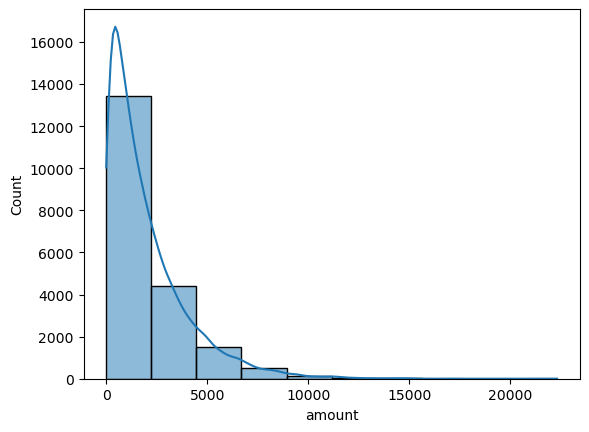

In [67]:
sns.histplot(x = 'amount', data = df, bins = 10,kde = True  )

<Axes: xlabel='txn_type', ylabel='count'>

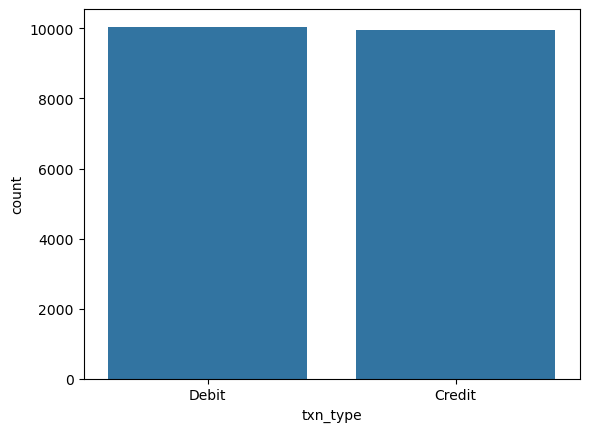

In [68]:
sns.countplot(x = 'txn_type' , data = df)

<Axes: xlabel='account_type', ylabel='count'>

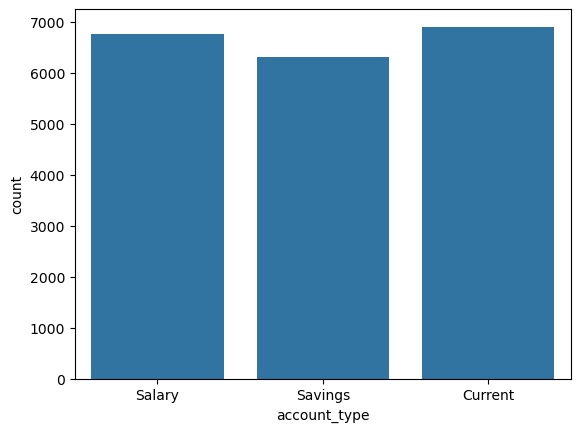

In [69]:
sns.countplot(x = 'account_type' , data = df)

<Axes: xlabel='status', ylabel='count'>

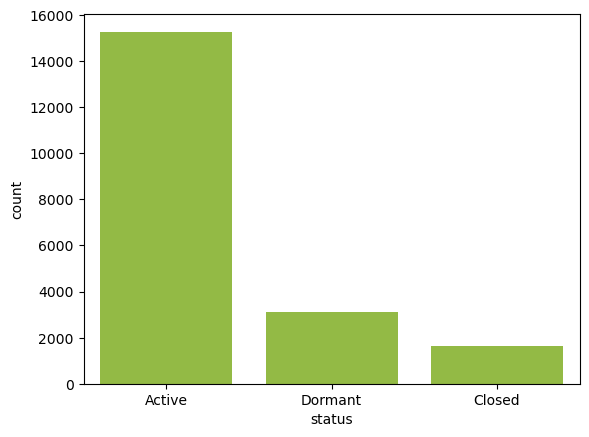

In [70]:
sns.countplot(x = 'status' , data = df,color = "yellowgreen")

<Axes: xlabel='gender', ylabel='count'>

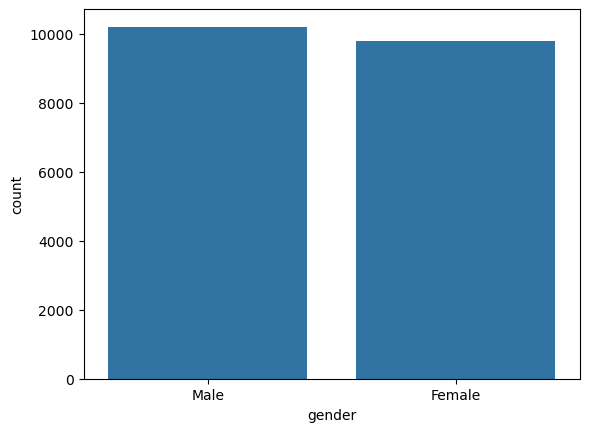

In [71]:
sns.countplot(x = 'gender' , data = df)

<Axes: xlabel='region', ylabel='count'>

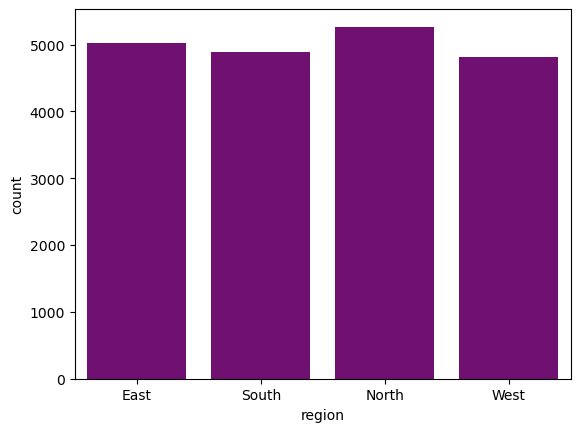

In [72]:
sns.countplot(x = 'region' , data = df, color = 'purple')

<Axes: xlabel='gender', ylabel='amount'>

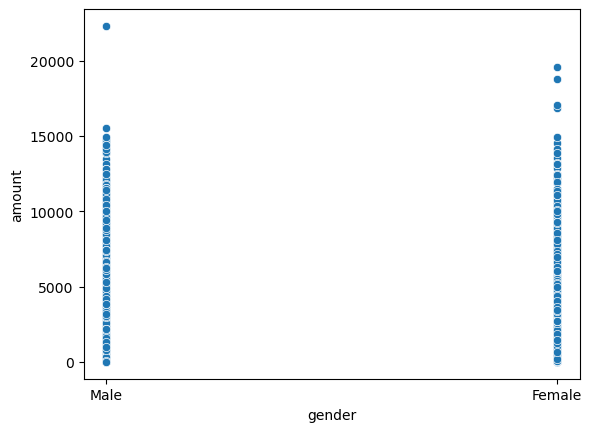

In [73]:
sns.scatterplot(x = 'gender' ,y = 'amount' , data = df)

<Axes: xlabel='account_type', ylabel='amount'>

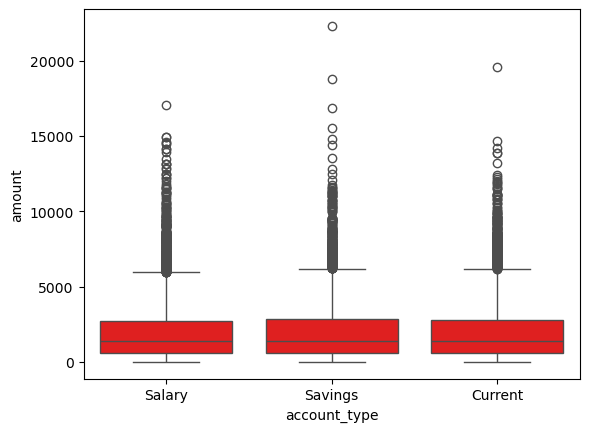

In [74]:
sns.boxplot(x = 'account_type' ,y = 'amount' , data = df, color = "red")

<Axes: xlabel='branch_code', ylabel='amount'>

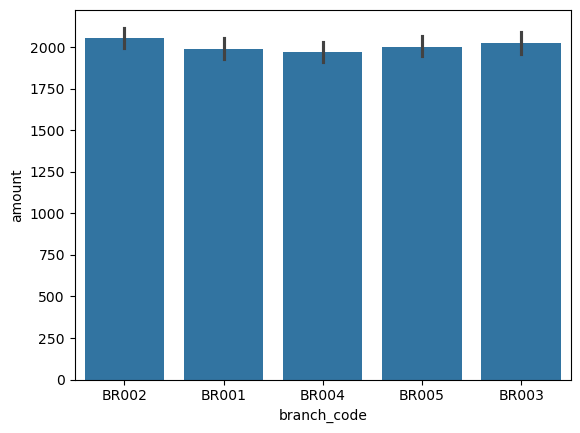

In [75]:
sns.barplot(x = 'branch_code' ,y = 'amount' , data = df) 

Top customers by spending

In [76]:
df.head()

,txn_id,account_id,txn_date,amount,txn_type,channel,customer_id,account_type,open_date,status,branch_code,name,gender,dob,join_date,region,occupation
0,500001,2371,2021-07-31,2881.78,Debit,Branch,1970,Salary,2021-07-22,Active,BR002,Ria Khan,Male,1998-05-14,2015-12-07,East,Self-Employed
1,500002,2829,2022-10-28,1625.53,Debit,ATM,1628,Savings,2022-04-16,Active,BR001,Arjun Patel,Male,1976-12-31,2018-08-01,East,Salaried
2,500003,2624,2023-02-01,4998.80,Debit,POS,1799,Current,2019-03-18,Active,BR001,Aarav Das,Female,1981-04-18,2018-03-02,South,Student
3,500004,2690,2025-06-11,2120.18,Credit,POS,1731,Salary,2024-08-15,Active,BR004,Sonia Ali,Female,1965-01-16,2021-06-21,East,Student
4,500005,2552,2024-09-15,368.87,Debit,ATM,1043,Salary,2023-04-24,Active,BR002,Rahul Menon,Male,1984-04-04,2021-03-31,South,Student


In [77]:
df.groupby(['customer_id','name'])['amount'].sum().reset_index().sort_values(by = 'amount',ascending = False).head(10)

,customer_id,name,amount
437,1551,Isha Sharma,210254.00
506,1648,Meera Verma,186372.19
371,1472,Gaurav Singh,175972.60
583,1747,Isha Pillai,173365.79
532,1681,Sonia Ghosh,166708.75
16,1021,Neha Mehta,154061.17
97,1125,Isha Pillai,150119.36
182,1236,Meera Sharma,149428.69
212,1275,Arjun Sharma,144840.40
343,1440,Dev Ghosh,143982.73


In [78]:
df.groupby(['customer_id','name'])['amount'].mean().reset_index()

,customer_id,name,amount
0,1001,Gaurav Ghosh,1811.019545
1,1002,Kiran Khan,2522.242667
2,1003,Sara Sharma,1443.765385
3,1004,Zoya Kulkarni,3186.384000
4,1006,Neha Bhat,1821.728214
...,...,...,...
769,1996,Rahul Iyer,2699.491765
770,1997,Aarav Menon,1906.385172
771,1998,Dev Khan,1631.693077
772,1999,Sonia Nair,2094.284000


In [79]:
df.groupby('account_type')['amount'].sum().reset_index().sort_values(by = 'amount', ascending= False).head(1)

,account_type,amount
0,Current,13876184.65


Find number of transactions per customer. Filter out the customers with less than or equal to 2 transactions.

In [80]:
txn_count = df.groupby('customer_id')['txn_id'].count().reset_index().rename(columns={'txn_id':'txn_count'})

In [81]:
txn_count

,customer_id,txn_count
0,1001,22
1,1002,15
2,1003,13
3,1004,15
4,1006,28
...,...,...
769,1996,34
770,1997,58
771,1998,78
772,1999,10


In [82]:
df = pd.merge(df , txn_count, on = 'customer_id', how = 'left')

In [83]:
df.head()

,txn_id,account_id,txn_date,amount,txn_type,channel,customer_id,account_type,open_date,status,branch_code,name,gender,dob,join_date,region,occupation,txn_count
0,500001,2371,2021-07-31,2881.78,Debit,Branch,1970,Salary,2021-07-22,Active,BR002,Ria Khan,Male,1998-05-14,2015-12-07,East,Self-Employed,21
1,500002,2829,2022-10-28,1625.53,Debit,ATM,1628,Savings,2022-04-16,Active,BR001,Arjun Patel,Male,1976-12-31,2018-08-01,East,Salaried,43
2,500003,2624,2023-02-01,4998.80,Debit,POS,1799,Current,2019-03-18,Active,BR001,Aarav Das,Female,1981-04-18,2018-03-02,South,Student,64
3,500004,2690,2025-06-11,2120.18,Credit,POS,1731,Salary,2024-08-15,Active,BR004,Sonia Ali,Female,1965-01-16,2021-06-21,East,Student,42
4,500005,2552,2024-09-15,368.87,Debit,ATM,1043,Salary,2023-04-24,Active,BR002,Rahul Menon,Male,1984-04-04,2021-03-31,South,Student,13


In [84]:
df[df['txn_count']<=2]

,txn_id,account_id,txn_date,amount,txn_type,channel,customer_id,account_type,open_date,status,branch_code,name,gender,dob,join_date,region,occupation,txn_count
3597,503598,3279,2021-12-09,306.29,Credit,Online,1980,Current,2021-06-16,Active,BR001,Ishaan Khanna,Female,1964-07-12,2020-03-02,South,Retired,2
9653,509654,3093,2023-05-12,158.83,Credit,POS,1706,Salary,2021-06-03,Active,BR001,Priya Iyer,Female,1961-09-20,2020-02-29,North,Self-Employed,2
9990,509991,3279,2022-09-06,2041.06,Debit,Branch,1980,Current,2021-06-16,Active,BR001,Ishaan Khanna,Female,1964-07-12,2020-03-02,South,Retired,2
17292,517293,3093,2024-02-25,2751.71,Credit,Online,1706,Salary,2021-06-03,Active,BR001,Priya Iyer,Female,1961-09-20,2020-02-29,North,Self-Employed,2
